In [1]:
# load the necessary functions
# for (fnm in list.files("/home/jovyan/shared_materials/rwwa", full.names = T)) source(fnm)

# import R libraries from WWA
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
from rpy2.robjects.vectors import ListVector

ro.r('''if (!requireNamespace("devtools", quietly = TRUE)) {install.packages("devtools", repos="https://cloud.r-project.org", quiet=TRUE)}''')
ro.r('devtools::install_github("WorldWeatherAttribution/rwwa")')
rwwa = importr("rwwa")
%load_ext rpy2.ipython

# print(ro.r('.libPaths()'))

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
R callback write-console: Using GitHub PAT from the git credential store.
  
R callback write-console: Downloading GitHub repo WorldWeatherAttribution/rwwa@HEAD
  


These packages have more recent versions available.
It is recommended to update all of them.
Which would you like to update?

1: All                                       
2: CRAN packages only                        
3: None                                      
4: RcppArmad... (15.0.2-2 -> 15.2.3-1) [CRAN]
5: gsl          (2.1-8    -> 2.1-9   ) [CRAN]

-- R CMD build -----------------------------------------------------------------
* checking for file 'C:\Users\jasper\AppData\Local\Temp\RtmpOsyNGk\remotes262c4fe412e\WorldWeatherAttribution-rwwa-236d9a6/DESCRIPTION' ... OK
* preparing 'rwwa':
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
Omitted 'LazyData' from DESCRIPTION
* building 'rwwa_0.1.1.tar.gz'



R callback write-console: Installing package into 'C:/Users/jasper/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)
  


# Synthesise results from observations and climate models

In [87]:
%%R
# load the observational results
df_obs <- read.csv("res-obs.csv", row.names = "X")

# colnames(df_obs) <- as.character(df_obs[1, ])
# df_obs <- df_obs[-1, ]
# df_obs <- type.convert(df_obs, as.is = TRUE)

In [88]:
%%R
df_obs

                        est       X2.5.      X97.5.
mu0              90.3858338  71.2990791 110.0438927
sigma0           36.2372216  26.9132885  44.1098885
alpha_gmst       17.3103650 -14.5477179  53.9939213
shape             0.1318083  -0.1177386   0.3078561
disp              0.4009170   0.3306290   0.4569685
event_magnitude 202.9775305 202.9775305 202.9775305
return_period    14.0272692   6.8876396  95.8343096
PR                2.7838882   0.2153585  15.9413711
dI_abs           44.7357641 -50.7697549  96.5430635
dI_rel           28.2705161 -20.0074753  90.7094620
aic             775.0027073 744.1568950 796.5393724
n                75.0000000 500.0000000   0.0000000


In [89]:
%%R
# load the climate model results
df_models <- read.csv("res-models_cordex.csv", row.names = "X")

# colnames(df_models) <- as.character(df_models[2, ])
# df_models <- df_models[-c(1,2), ]
# df_models <- type.convert(df_models, as.is = TRUE)

In [90]:
%%R
df_models

                                                           value...gmst..rp20.
cccma_canesm2-clmcom_clm_cclm4_8_17.eval_sigma0_est               1.087828e+00
cccma_canesm2-clmcom_clm_cclm4_8_17.eval_sigma0_lower             9.901518e-01
cccma_canesm2-clmcom_clm_cclm4_8_17.eval_sigma0_upper             1.106263e+00
cccma_canesm2-clmcom_clm_cclm4_8_17.eval_shape_est               -1.641816e-01
cccma_canesm2-clmcom_clm_cclm4_8_17.eval_shape_lower             -2.492829e-01
cccma_canesm2-clmcom_clm_cclm4_8_17.eval_shape_upper             -4.430349e-02
cccma_canesm2-clmcom_clm_cclm4_8_17.rp_value                      1.777547e+01
cccma_canesm2-clmcom_clm_cclm4_8_17.attr_PR_est                   4.552358e+01
cccma_canesm2-clmcom_clm_cclm4_8_17.attr_PR_lower                 8.612959e+00
cccma_canesm2-clmcom_clm_cclm4_8_17.attr_PR_upper                 8.943313e+02
cccma_canesm2-clmcom_clm_cclm4_8_17.attr_dI-abs_est               1.876013e+00
cccma_canesm2-clmcom_clm_cclm4_8_17.attr_dI-abs_lowe

In [91]:
%%R
# list the models to INCLUDE in the analysis (use the results spreadsheet to populate the list)
include <- c("CCCma-CanESM2_CLMcom-CCLM4-8-17",
             "CNRM-CERFACS-CNRM-CM5_CNRM-ALADIN63",
             "MOHC-HadGEM2-ES_KNMI-RACMO22E",
             "MOHC-HadGEM2-ES_MOHC-HadREM3-GA7-05",
             "MPI-M-MPI-ESM-LR_DMI-HIRHAM5")

# filter to retain only the models that passed model evaluation
df_models <- df_models[rownames(df_models) %in% include,]

In [94]:
%%R
df_models

numeric(0)


In [92]:
%%R
# if looking at temperature data / 'shift' fit, use "abs"; if looking at precipitation / 'fixeddisp', use "rel"
synthesis_type <- "abs"

In [93]:
%%R
# change in intensity from past-present

synth_dI_attr <- synthesis(obs_in = df_obs[,grepl(paste0("dI.", synthesis_type), colnames(df_obs))], 
                           models_in = df_models[,grepl("attr_dI", colnames(df_models))], 
                           synth_type = synthesis_type)

# change in likelihood from past-present (if there are any infinite values in the PRs, replace them with estimated values)
synth_PR_attr <- synthesis(obs_in = infer_infinite(df_obs[,grepl("PR", colnames(df_obs))]), 
                           models_in = infer_infinite(df_models[,grepl("attr_PR", colnames(df_models))]), 
                           synth_type = "PR")

# if you see error/warning messages below, you probably have infinite best estimates in your observations - ask us how to handle these

Error in if (is.na(unlist(obs_in))[1]) { : 
  missing value where TRUE/FALSE needed


RInterpreterError: Failed to parse and evaluate line '# change in intensity from past-present\n\nsynth_dI_attr <- synthesis(obs_in = df_obs[,grepl(paste0("dI.", synthesis_type), colnames(df_obs))], \n                           models_in = df_models[,grepl("attr_dI", colnames(df_models))], \n                           synth_type = synthesis_type)\n\n# change in likelihood from past-present (if there are any infinite values in the PRs, replace them with estimated values)\nsynth_PR_attr <- synthesis(obs_in = infer_infinite(df_obs[,grepl("PR", colnames(df_obs))]), \n                           models_in = infer_infinite(df_models[,grepl("attr_PR", colnames(df_models))]), \n                           synth_type = "PR")\n\n# if you see error/warning messages below, you probably have infinite best estimates in your observations - ask us how to handle these\n'.
R error message: 'Error in if (is.na(unlist(obs_in))[1]) { : \n  missing value where TRUE/FALSE needed'

In [ ]:
%%R
# change in intensity from present-future
synth_dI_proj <- synthesis(obs_in = NA, 
                           models_in = df_models[,grepl("proj_dI", colnames(df_models))], 
                           synth_type = synthesis_type)

# change in likelihood from present-future
synth_PR_proj <- synthesis(obs_in = NA, 
                           models_in = df_models[,grepl("proj_PR", colnames(df_models))], 
                           synth_type = "PR")

In [ ]:
%%R
# save all the synthesised results
write.csv(synth_dI_attr$df, "synth_dI_attr.csv")
write.csv(synth_PR_attr$df, "synth_PR_attr.csv")
write.csv(synth_dI_proj$df, "synth_dI_proj.csv")
write.csv(synth_PR_proj$df, "synth_PR_proj.csv")

Error in eval(expr, p) : object 'synth_dI_attr' not found


RInterpreterError: Failed to parse and evaluate line '# save all the synthesised results\nwrite.csv(synth_dI_attr$df, "synth_dI_attr.csv")\nwrite.csv(synth_PR_attr$df, "synth_PR_attr.csv")\nwrite.csv(synth_dI_proj$df, "synth_dI_proj.csv")\nwrite.csv(synth_PR_proj$df, "synth_PR_proj.csv")\n'.
R error message: "Error in eval(expr, p) : object 'synth_dI_attr' not found"

## Synthesis figures

In [ ]:
%%R
# put two figures next to each other
prep_window(c(1,2),
            h = 5,                    # height of the figure (ins)
            w = 5,                    # width of each panel (ins)
            oma = c(0,20,0,0),        # increase second number until model names fit in margin
            mar = c(3,0.5,2,0.5))     # shouldn't need to be changed

# set the x-axis (xlim) so that both the past & future changes use the same scaling
plot_synthesis(synth_dI_attr, add_space = F, main = "(a) Change in intensity", xlim = c(-2,8))
plot_synthesis(synth_PR_attr, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = c(1e-2, 1e8))

Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  object 'synth_dI_attr' not found


RInterpreterError: Failed to parse and evaluate line '# put two figures next to each other\nprep_window(c(1,2),\n            h = 5,                    # height of the figure (ins)\n            w = 5,                    # width of each panel (ins)\n            oma = c(0,20,0,0),        # increase second number until model names fit in margin\n            mar = c(3,0.5,2,0.5))     # shouldn\'t need to be changed\n\n# set the x-axis (xlim) so that both the past & future changes use the same scaling\nplot_synthesis(synth_dI_attr, add_space = F, main = "(a) Change in intensity", xlim = c(-2,8))\nplot_synthesis(synth_PR_attr, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = c(1e-2, 1e8))\n'.
R error message: "Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : \n  object 'synth_dI_attr' not found"

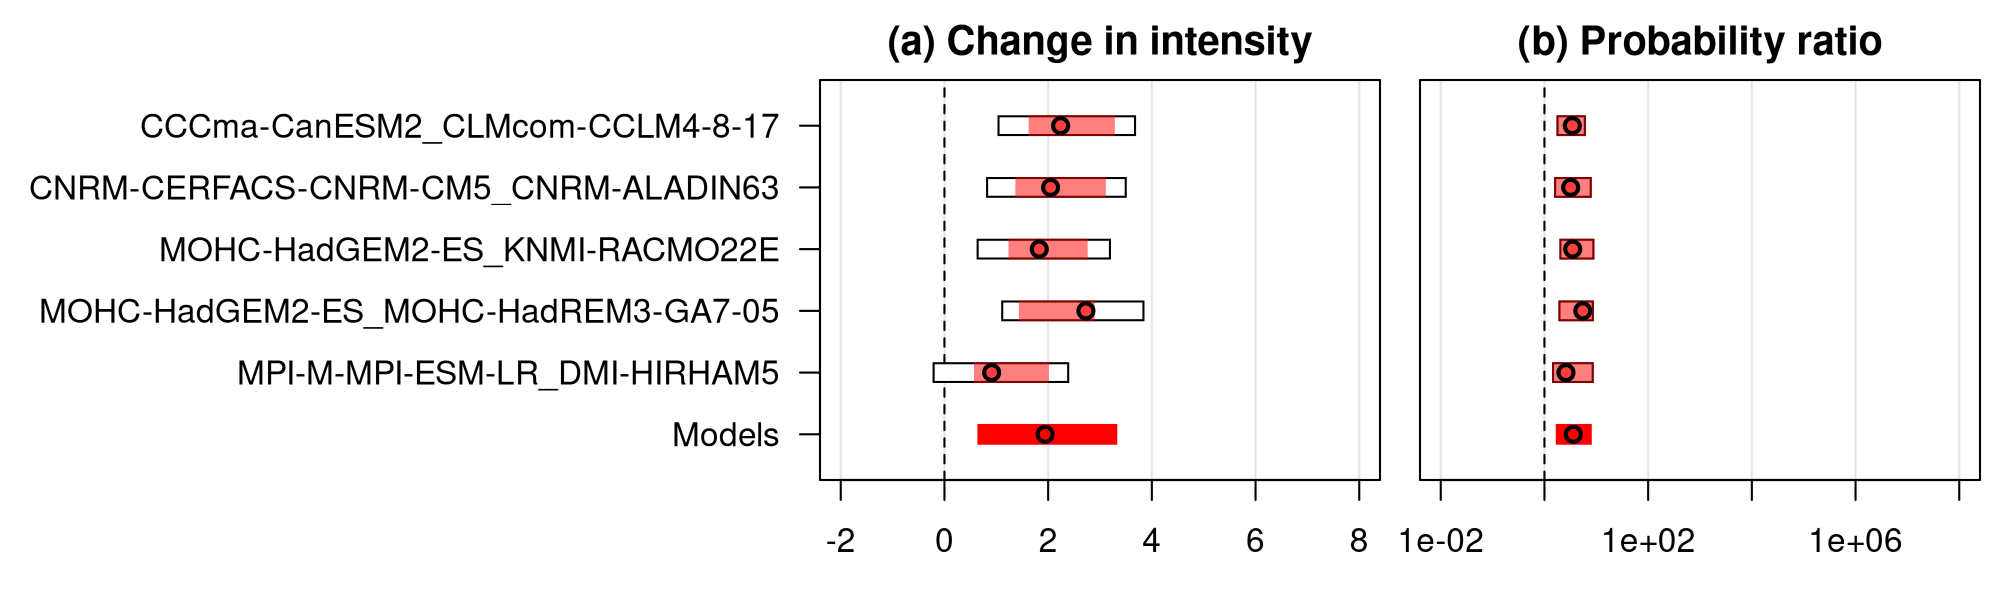

In [ ]:
%%R
prep_window(c(1,2),
            h = 3,                    # height of the figure (ins)
            w = 5,                    # width of each panel (ins)
            oma = c(0,20,0,0),        # increase second number until model names fit in margin
            mar = c(3,0.5,2,0.5))     # shouldn't need to be changed

# set the x-axis (xlim) so that both the past & future changes use the same scaling
plot_synthesis(synth_dI_proj, add_space = F, main = "(a) Change in intensity", xlim = c(-2,8))
plot_synthesis(synth_PR_proj, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = c(1e-2, 1e8))

## Produce figures of the synthesis

In [ ]:
%%R
png("synth-fig_attr.png", height = 360, width = 480*1.5); par(mfrow = c(1,2), oma = c(0,20,0,0), mar = c(3,0.5,2,0.5)); {
    # set the x-axis (xlim) so that both the past & future changes use the same scaling
    plot_synthesis(synth_dI_attr, add_space = F, main = "(a) Change in intensity", xlim = c(-2,8))
    plot_synthesis(synth_PR_attr, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = c(1e-2, 1e8))
}; dev.off()

pdf 
  2

In [ ]:
%%R
png("synth-fig_proj.png", height = 240, width = 480*1.5); par(mfrow = c(1,2), oma = c(0,20,0,0), mar = c(3,0.5,2,0.5)); {
    # set the x-axis (xlim) so that both the past & future changes use the same scaling
    plot_synthesis(synth_dI_proj, add_space = F, main = "(a) Change in intensity", xlim = c(-2,8))
    plot_synthesis(synth_PR_proj, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = c(1e-2, 1e8))
}; dev.off()

pdf 
  2